# Outlier Analysis

This notebook evaluates whether extreme values in the engineered fraud-detection dataset represent useful anomaly signal or problematic noise. The goal is to review outliers systematically before later feature selection and modeling decisions.


## 1. Objectives

This notebook focuses on the following tasks:

- load the engineered dataset created in the previous notebook
- quantify IQR-based outliers across raw, transformed, ratio, and interaction features
- compare outlier behavior across fraud and non-fraud classes
- visualize the most outlier-prone engineered features
- generate feature-level recommendations for downstream handling
- save tables, figures, and a written report for later feature selection and modeling


## Output Guide

- **IQR outlier summary:** shows lower and upper bounds, outlier counts, and outlier rates for reviewed features.
- **Class-wise outlier summary:** shows whether outlier regions are concentrated in fraud or non-fraud observations.
- **Outlier handling recommendation table:** gives feature-level guidance on whether outliers should be preserved or handled carefully.
- **Outlier visuals:** help compare how frequently extreme values appear and whether they align with fraud cases.
- **Outlier report:** summarizes what the outlier patterns imply for the next stage of modeling.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path("..").resolve()))

from src.config import (
    ARTIFACTS_DIR,
    ENGINEERED_DATA_FILE,
    FEATURE_COLUMNS_FILE,
    PROJECT_ROOT,
    TARGET_COLUMN,
)
from src.data.data_loader import load_engineered_data

NOTEBOOK_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "09_outlier_analysis"
NOTEBOOK_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "09_outlier_analysis"
NOTEBOOK_TABLES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

print("Imports OK")
print(f"  Engineered data : {ENGINEERED_DATA_FILE}")
print(f"  Feature list    : {FEATURE_COLUMNS_FILE}")
print(f"  Tables dir      : {NOTEBOOK_TABLES_DIR}")
print(f"  Figures dir     : {NOTEBOOK_FIGURES_DIR}")


Imports OK
  Engineered data : /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/data/processed/creditcard_engineered.csv
  Feature list    : /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/feature_columns.json
  Tables dir      : /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/09_outlier_analysis
  Figures dir     : /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/09_outlier_analysis


## 2. Load Engineered Data


In [ ]:
df = load_engineered_data()

print("Engineered dataset shape:", df.shape)
df.head()


Engineered dataset shape: (283726, 23)


,V17,V14,V12,V10,V16,V3,V7,V11,V4,V18,...,time_day_fraction,amount_to_mean_ratio,amount_to_median_ratio,amount_V17_interaction,V17_V14_interaction,V17_V12_interaction,V14_V12_interaction,V17_V10_interaction,V17_V16_interaction,Class
0,0.207971,-0.311169,-0.617801,0.090794,-0.470401,2.536347,0.239599,-0.551600,1.378155,0.025791,...,0.000000,1.691143,6.800909,1.042926,-0.064714,-0.128485,0.192241,0.018883,-0.097830,0
1,-0.114805,-0.143772,1.065235,-0.166974,0.463917,0.166480,-0.078803,1.612727,0.448154,-0.183361,...,0.000000,0.030405,0.122273,-0.149892,0.016506,-0.122294,-0.153151,0.019169,-0.053260,0
2,1.109969,-0.165946,0.066084,0.207643,-2.890083,1.773209,0.791461,0.624501,0.379780,-0.121359,...,0.000012,4.279965,17.211818,6.592415,-0.184195,0.073351,-0.010966,0.230477,-3.207904,0
3,-0.684093,-0.287924,0.178228,-0.054952,-1.059647,1.792993,0.237609,-0.226487,-0.863291,1.965775,...,0.000012,1.395911,5.613636,-3.300273,0.196967,-0.121925,-0.051316,0.037592,0.724897,0
4,-0.237033,-1.119670,0.538196,0.753074,-0.451449,1.548718,0.592941,-0.822843,0.403034,-0.038195,...,0.000023,0.791092,3.181364,-1.010363,0.265399,-0.127570,-0.602601,-0.178504,0.107008,0


## 3. Select Features for Outlier Review

The outlier review focuses on the engineered feature set carried forward from the previous notebook. Features are grouped so that later interpretation can distinguish raw variables from log, ratio, time-derived, and interaction-based features.


In [17]:
feature_columns = json.loads(FEATURE_COLUMNS_FILE.read_text(encoding="utf-8"))

feature_category_path = PROJECT_ROOT / "reports" / "tables" / "08_feature_engineering" / "final_feature_categories.json"
if not feature_category_path.exists():
    print("WARNING: feature_category_map not found — all categories labeled UNKNOWN")
    feature_category_map = {feature: "UNKNOWN" for feature in feature_columns}
else:
    feature_category_map = json.loads(feature_category_path.read_text(encoding="utf-8"))

outlier_review_features = [feature for feature in feature_columns if feature in df.columns]
feature_review_summary = pd.DataFrame({
    "feature": outlier_review_features,
    "feature_category": [feature_category_map.get(feature, "UNKNOWN") for feature in outlier_review_features],
})
feature_review_summary.to_csv(NOTEBOOK_TABLES_DIR / "outlier_review_feature_list.csv", index=False)
feature_review_summary


,feature,feature_category
0,V17,PCA
1,V14,PCA
2,V12,PCA
3,V10,PCA
4,V16,PCA
5,V3,PCA
6,V7,PCA
7,V11,PCA
8,V4,PCA
9,V18,PCA


## 4. Compute IQR Outlier Summary

This section uses the IQR rule as a consistent screening method across all reviewed features. The goal is not to remove records automatically, but to identify where extreme-value regions are concentrated.


In [14]:
iqr_rows = []
outlier_mask_df = pd.DataFrame(index=df.index)

for feature in outlier_review_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue  # skip constant/near-constant features
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df[feature] < lower_bound) | (df[feature] > upper_bound)
    outlier_mask_df[feature] = outlier_mask
    iqr_rows.append({
        "feature": feature,
        "feature_category": feature_category_map.get(feature, "UNKNOWN"),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_mask.sum()),
        "outlier_rate": outlier_mask.mean(),
    })

iqr_outlier_summary = pd.DataFrame(iqr_rows).sort_values("outlier_rate", ascending=False)
iqr_outlier_summary.to_csv(NOTEBOOK_TABLES_DIR / "iqr_outlier_summary.csv", index=False)
iqr_outlier_summary


,feature,feature_category,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_rate
20,V17_V10_interaction,INTERACTION,-0.211363,0.132239,0.343602,-0.726766,0.647642,45598,0.160711
19,V14_V12_interaction,INTERACTION,-0.196004,0.194788,0.390791,-0.782191,0.780975,45182,0.159245
17,V17_V14_interaction,INTERACTION,-0.241583,0.086841,0.328424,-0.734220,0.579477,40742,0.143596
21,V17_V16_interaction,INTERACTION,-0.288445,0.088910,0.377356,-0.854479,0.654943,37377,0.131736
18,V17_V12_interaction,INTERACTION,-0.299892,0.096127,0.396019,-0.893921,0.690155,35115,0.123764
11,Amount,RAW,5.600000,77.510000,71.910000,-102.265000,185.375000,31685,0.111675
14,amount_to_mean_ratio,RATIO,0.063296,0.876090,0.812793,-1.155893,2.095279,31685,0.111675
15,amount_to_median_ratio,RATIO,0.254545,3.523182,3.268636,-4.648409,8.426136,31685,0.111675
16,amount_V17_interaction,RATIO,-1.188546,1.063972,2.252519,-4.567325,4.442750,20352,0.071731
2,V12,PCA,-0.406198,0.616976,1.023174,-1.940959,2.151738,15282,0.053862


## 5. Compare Outliers by Class

Fraud detection rarely benefits from blanket outlier removal. This section checks whether outlier regions are disproportionately associated with fraud cases, which would argue for preserving those extremes.


In [7]:
classwise_rows = []

for feature in outlier_review_features:
    mask = outlier_mask_df[feature]
    total_outliers = int(mask.sum())
    fraud_outliers = int(df.loc[mask, TARGET_COLUMN].sum()) if total_outliers > 0 else 0
    legit_outliers = total_outliers - fraud_outliers
    fraud_rate_among_outliers = fraud_outliers / total_outliers if total_outliers > 0 else 0.0
    fraud_rate_overall = df[TARGET_COLUMN].mean()
    lift_vs_base_fraud_rate = fraud_rate_among_outliers / fraud_rate_overall if fraud_rate_overall > 0 else 0.0
    classwise_rows.append({
        "feature": feature,
        "feature_category": feature_category_map.get(feature, "UNKNOWN"),
        "total_outliers": total_outliers,
        "legit_outliers": legit_outliers,
        "fraud_outliers": fraud_outliers,
        "fraud_rate_among_outliers": fraud_rate_among_outliers,
        "base_fraud_rate": fraud_rate_overall,
        "lift_vs_base_fraud_rate": lift_vs_base_fraud_rate,
    })

classwise_outlier_summary = pd.DataFrame(classwise_rows).sort_values(["lift_vs_base_fraud_rate", "fraud_outliers"], ascending=False)
classwise_outlier_summary.to_csv(NOTEBOOK_TABLES_DIR / "classwise_outlier_summary.csv", index=False)
classwise_outlier_summary.head(15)


,feature,feature_category,total_outliers,legit_outliers,fraud_outliers,fraud_rate_among_outliers,base_fraud_rate,lift_vs_base_fraud_rate
7,V11,PCA,735,459,276,0.375510,0.001667,225.247375
5,V3,PCA,3306,3013,293,0.088627,0.001667,53.162178
0,V17,PCA,7353,6974,379,0.051544,0.001667,30.918089
4,V16,PCA,8180,7847,333,0.040709,0.001667,24.419059
3,V10,PCA,9345,8965,380,0.040663,0.001667,24.391712
6,V7,PCA,8839,8556,283,0.032017,0.001667,19.205309
9,V18,PCA,7468,7249,219,0.029325,0.001667,17.590484
1,V14,PCA,14060,13649,411,0.029232,0.001667,17.534545
8,V4,PCA,11094,10794,300,0.027042,0.001667,16.220756
2,V12,PCA,15282,14892,390,0.025520,0.001667,15.308139


### Amount Outlier Fraud Check

The summary below answers a direct fraud-vs-outlier question for `Amount`: do transactions above the IQR upper bound contain a higher fraud rate than non-outlier transactions?


In [11]:
amount_row = iqr_outlier_summary.loc[iqr_outlier_summary["feature"] == "Amount"].iloc[0]
upper_bound = amount_row["upper_bound"]
outlier_flag = df["Amount"] > upper_bound

amount_outlier_fraud_summary = (
    df.assign(amount_outlier_flag=outlier_flag)
    .groupby("amount_outlier_flag")[TARGET_COLUMN]
    .agg(fraud_rate="mean", transaction_count="count", fraud_count="sum")
    .reset_index()
)
amount_outlier_fraud_summary["upper_bound"] = upper_bound
amount_outlier_fraud_summary.to_csv(NOTEBOOK_TABLES_DIR / "amount_outlier_fraud_summary.csv", index=False)
amount_outlier_fraud_summary


,amount_outlier_flag,fraud_rate,transaction_count,fraud_count,upper_bound
0,False,0.001531,252041,386,185.375
1,True,0.002746,31685,87,185.375


Amount outliers above the IQR upper bound show a higher fraud rate than non-outlier transactions, which suggests mild fraud enrichment and supports keeping these extreme values for modeling rather than removing them.


## 6. Visualize High-Risk Outlier Features

The charts below highlight features with the highest outlier rates and a small set of engineered features that deserve class-wise visual inspection.


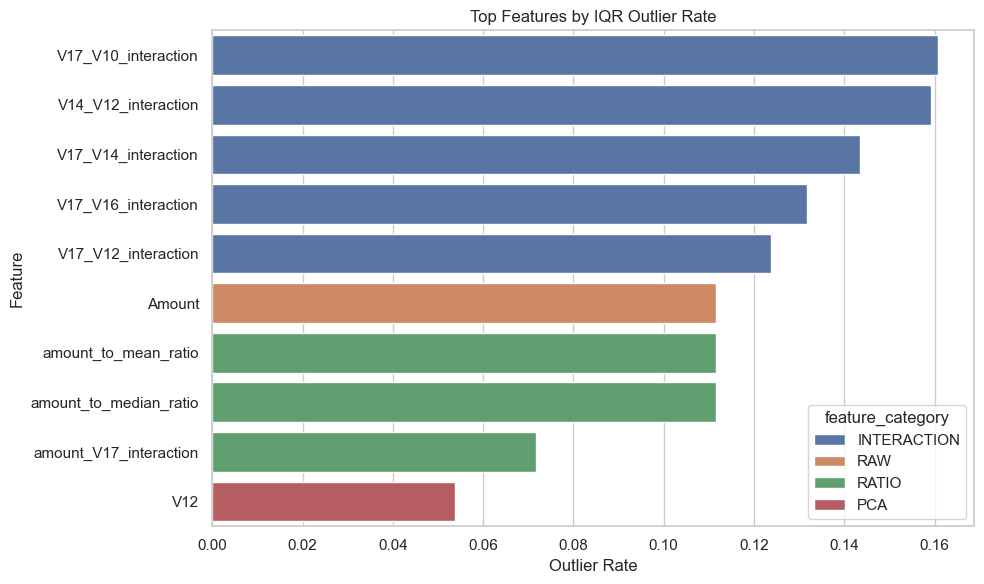

In [12]:
plot_df = iqr_outlier_summary.head(10).copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="outlier_rate", y="feature", hue="feature_category")
plt.title("Top Features by IQR Outlier Rate")
plt.xlabel("Outlier Rate")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "top_outlier_rate_features.png", dpi=300, bbox_inches="tight")
plt.show()


The outlier-rate chart shows that interaction features dominate the top tail positions, which suggests engineered pairwise PCA signals create the most extreme value regions in the dataset. `Amount` and the amount-based ratio features also appear high on the list, reinforcing that transaction size remains an important source of unusual behavior even after transformation.


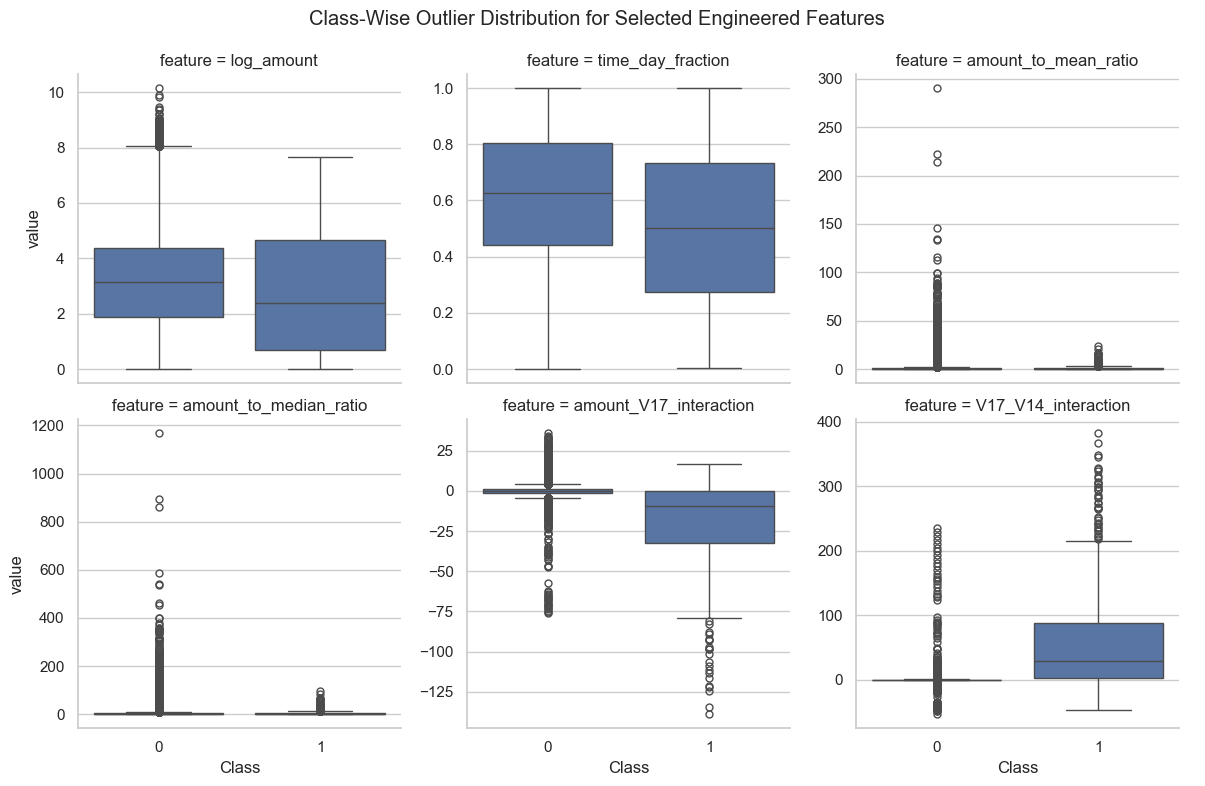

In [13]:
focus_features = [
    feature
    for feature in [
        "log_amount",
        "time_day_fraction",
        "amount_to_mean_ratio",
        "amount_to_median_ratio",
        "amount_V17_interaction",
        "V17_V14_interaction",
    ]
    if feature in df.columns
]

plot_long_df = df.melt(id_vars=TARGET_COLUMN, value_vars=focus_features, var_name="feature", value_name="value")
g = sns.catplot(
    data=plot_long_df,
    x=TARGET_COLUMN,
    y="value",
    col="feature",
    col_wrap=3,
    kind="box",
    sharey=False,
    height=4,
)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Class-Wise Outlier Distribution for Selected Engineered Features")
g.savefig(NOTEBOOK_FIGURES_DIR / "selected_feature_outlier_boxes.png", dpi=300, bbox_inches="tight")
plt.show()


`log_amount` and the amount-based ratio features show broader spread in fraud observations, which suggests fraudulent transactions cluster around unusual magnitudes rather than following the normal spending profile. The interaction features also show stronger tail spread for fraud cases, supporting the idea that fraud is more visible when abnormal amount behavior combines with high-signal PCA patterns.


## 7. Outlier Handling Recommendation Table

These recommendations are intended for downstream modeling decisions, not automatic deletion. In fraud detection, extreme values often represent the minority-class signal we most want to preserve.

### Outlier Interpretation (Business Context)

In fraud detection, extreme values are not necessarily noise. They often represent abnormal behavior, which is exactly what fraud looks like.

Therefore:
- Outliers will NOT be removed blindly
- They will be preserved for modeling

### Outlier Handling Strategy

| Feature Type | Action |
|-------------|--------|
| PCA Features | Keep (already transformed) |
| Amount | Apply log transform |
| Ratio Features | Scale / log if needed |
| Interaction Features | Keep, handle via scaling |
| Rows | Do NOT remove |

### Model Sensitivity to Outliers

- Logistic Regression -> sensitive -> needs scaling
- Tree models (RF, XGBoost) -> robust -> no issue

Therefore:
Outliers will be handled during modeling via scaling, not removal.

### Final Decision for Feature Engineering

- No rows removed
- Amount -> log transform
- Interaction features -> kept
- Scaling deferred to modeling pipeline


In [10]:
recommendation_df = iqr_outlier_summary.merge(
    classwise_outlier_summary[["feature", "fraud_rate_among_outliers", "lift_vs_base_fraud_rate"]],
    on="feature",
    how="left",
)

def recommend_action(row):
    if row["lift_vs_base_fraud_rate"] >= 2:
        return "Preserve outliers; tail region is meaningfully fraud-enriched."
    if row["feature_category"] in {"INTERACTION", "RATIO", "LOG"}:
        return "Preserve for modeling review; engineered extremes may encode anomaly strength."
    if row["outlier_rate"] >= 0.1:
        return "Review with robust models or optional capping sensitivity test."
    return "Keep as-is; no strong evidence that capping is necessary at this stage."

recommendation_df["recommended_action"] = recommendation_df.apply(recommend_action, axis=1)
recommendation_df = recommendation_df.sort_values(["lift_vs_base_fraud_rate", "outlier_rate"], ascending=False)
recommendation_df.to_csv(NOTEBOOK_TABLES_DIR / "outlier_handling_recommendations.csv", index=False)
recommendation_df[["feature", "feature_category", "outlier_rate", "fraud_rate_among_outliers", "lift_vs_base_fraud_rate", "recommended_action"]].head(15)


,feature,feature_category,outlier_rate,fraud_rate_among_outliers,lift_vs_base_fraud_rate,recommended_action
18,V11,PCA,0.002591,0.375510,225.247375,Preserve outliers; tail region is meaningfully...
17,V3,PCA,0.011652,0.088627,53.162178,Preserve outliers; tail region is meaningfully...
16,V17,PCA,0.025916,0.051544,30.918089,Preserve outliers; tail region is meaningfully...
14,V16,PCA,0.028831,0.040709,24.419059,Preserve outliers; tail region is meaningfully...
12,V10,PCA,0.032937,0.040663,24.391712,Preserve outliers; tail region is meaningfully...
13,V7,PCA,0.031153,0.032017,19.205309,Preserve outliers; tail region is meaningfully...
15,V18,PCA,0.026321,0.029325,17.590484,Preserve outliers; tail region is meaningfully...
10,V14,PCA,0.049555,0.029232,17.534545,Preserve outliers; tail region is meaningfully...
11,V4,PCA,0.039101,0.027042,16.220756,Preserve outliers; tail region is meaningfully...
9,V12,PCA,0.053862,0.025520,15.308139,Preserve outliers; tail region is meaningfully...


## 8. Connection to Modeling and Decision System

- Outlier review in fraud detection should focus on whether extreme values increase fraud concentration rather than treating all tails as data-quality errors.
- Ratio and interaction features deserve special caution because large values may reflect the exact anomaly structure later models need.
- Robust models and sensitivity testing are preferred over blind trimming when outlier regions show fraud enrichment.
- The results here should guide the next feature-selection stage by separating useful anomaly features from features that only add noise.

### Decision System Bridge

| Outlier Pattern | Implication for Decision System |
|---|---|
| High lift in fraud-enriched features | Strengthens `BLOCK` threshold |
| Moderate lift features | Informs `REVIEW` zone |
| No lift | Safe to treat as noise |


## 9. Key Insights

- Features with high outlier rates are not automatically weak; in fraud detection they may represent the main minority-class pattern.
- Ratio and interaction features should be judged partly by fraud concentration in their tails, not only by how extreme they appear numerically.
- Outlier handling should remain feature-specific and evidence-based.
- The engineered dataset should move forward with preserved tails unless later modeling tests show a clear benefit from capping.
- IQR is a univariate method and does not capture multivariate outliers. Isolation Forest will be evaluated at the modeling stage to identify transactions that are anomalous across feature combinations.


## 10. Next Step

The next notebook should narrow the engineered feature space for modeling through feature selection or targeted model-based evaluation.


In [ ]:
outlier_analysis_report = f"""# Outlier Analysis Report

## Key Findings

- The notebook reviews IQR-based outlier behavior across the engineered fraud-detection feature set rather than removing extremes automatically.
- Class-wise outlier analysis is used to determine whether tail regions are fraud-enriched and therefore potentially valuable for modeling.
- Ratio and interaction features receive special attention because engineered magnitude effects may amplify the anomaly signal.
- A direct `Amount` outlier check is included so the notebook explicitly tests whether high-amount outlier regions contain more fraud than non-outlier transactions.

## Outlier Interpretation

- Extreme values should be interpreted as candidate fraud signal first and only as potential noise second.
- In fraud detection, extreme values are not necessarily noise; they often represent abnormal behavior, which is exactly what fraud looks like.
- Outliers will not be removed blindly and should be preserved for modeling unless later evidence shows a clear benefit from targeted handling.
- Features such as `log_amount`, amount-based ratios, and PCA interactions are especially important because their tails may encode unusual transaction behavior.
- Any handling recommendations should be evaluated with downstream model sensitivity checks rather than applied blindly.

## Outlier Handling Strategy

| Feature Type | Action |
|-------------|--------|
| PCA Features | Keep (already transformed) |
| Amount | Apply log transform |
| Ratio Features | Scale / log if needed |
| Interaction Features | Keep, handle via scaling |
| Rows | Do NOT remove |

### Model Sensitivity to Outliers

- Logistic Regression -> sensitive -> needs scaling
- Tree models (RF, XGBoost) -> robust -> no issue

Therefore:
Outliers will be handled during modeling via scaling, not removal.

## Final Decision for Feature Engineering

- No rows removed
- Amount -> log transform
- Interaction features -> kept
- Scaling deferred to modeling pipeline

## Connection to Modeling and Decision System

- Fraud-enriched outlier regions can strengthen downstream `BLOCK` and `REVIEW` decisions by making anomaly-heavy transactions easier to separate.
- Robust modeling choices are preferable when outlier structure appears informative.
- The outlier review results should be used to inform the next feature-selection notebook rather than to justify broad row removal.

### Decision System Bridge

| Outlier Pattern | Implication for Decision System |
|---|---|
| High lift in fraud-enriched features | Strengthens `BLOCK` threshold |
| Moderate lift features | Informs `REVIEW` zone |
| No lift | Safe to treat as noise |

## Saved Tables

- `reports/tables/09_outlier_analysis/outlier_review_feature_list.csv`
- `reports/tables/09_outlier_analysis/iqr_outlier_summary.csv`
- `reports/tables/09_outlier_analysis/classwise_outlier_summary.csv`
- `reports/tables/09_outlier_analysis/amount_outlier_fraud_summary.csv`
- `reports/tables/09_outlier_analysis/outlier_handling_recommendations.csv`
- `reports/tables/09_outlier_analysis/outlier_analysis_report.md`

## Saved Figures

- `reports/figures/09_outlier_analysis/top_outlier_rate_features.png`
- `reports/figures/09_outlier_analysis/selected_feature_outlier_boxes.png`
"""

report_path = NOTEBOOK_TABLES_DIR / "outlier_analysis_report.md"
report_path.write_text(outlier_analysis_report, encoding="utf-8")
print(f"Outlier analysis report saved to: {report_path}")
